# 03 — Baseline Models and LSTM Training

**Purpose.** Train traditional ML baselines (KNN, Random Forest) and a PyTorch LSTM from scratch on the weekly journey sequences, with a leakage-safe evaluation design:

1. **Grouped split by household** — no household appears in both train and test.
2. **Train-only scaling** — the scaler is fit on training data only.
3. **Class weights** — to handle label imbalance.
4. **Train/validation curves** — to show fit quality for the report.

**Inputs:** `sequences_x.npy`, `labels_y.npy`, `sample_index.parquet` from notebook 02  
**Outputs:** trained model, scaler, split indices, and metrics under `artifacts/` and `reports/`


## 1. Setup


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.append(str(REPO_ROOT / 'src'))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from campaign_strategist.config import ARTIFACT_DIR, CAMPAIGN_CLASSES, PROCESSED_DATA_DIR, PROJECT_ROOT
from campaign_strategist.baselines import flatten_sequences
from campaign_strategist.model import save_model
from campaign_strategist.training import (
    classification_metrics,
    grouped_train_val_test_split,
    predict_labels,
    scale_splits,
    train_lstm,
)
from campaign_strategist.viz import BLUE, ORANGE, apply_report_style, clean_label, despine, save_figure

apply_report_style()
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'reports' / 'tables').mkdir(parents=True, exist_ok=True)

## 2. Load Model-Ready Data


In [2]:
x = np.load(PROCESSED_DATA_DIR / 'sequences_x.npy')
y = np.load(PROCESSED_DATA_DIR / 'labels_y.npy')
sample_index = pd.read_parquet(PROCESSED_DATA_DIR / 'sample_index.parquet')

assert len(x) == len(y) == len(sample_index)
print(f'Sequences: {x.shape} | labels: {y.shape} | households: {sample_index.household_id.nunique():,}')
print(sample_index['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Sequences: (28499, 12, 19) | labels: (28499,) | households: 1,950
label
price_led_coupon           29.3%
cross_sell_bundle          27.9%
win_back_reminder          17.5%
loyalty_reward             10.7%
seasonal_spotlight          9.4%
new_customer_onboarding     5.2%
Name: proportion, dtype: str


## 3. Grouped Train / Validation / Test Split

We split **by household** so overlapping 12-week windows from the same customer cannot appear in more than one split. This avoids optimistic scores from near-duplicate journeys.


In [3]:
groups = sample_index['household_id'].to_numpy()
split = grouped_train_val_test_split(x, y, groups, test_size=0.2, val_size=0.15, random_state=RANDOM_STATE)

print(f'train {len(split.train_idx):,} | val {len(split.val_idx):,} | test {len(split.test_idx):,}')
print('Households —',
      f'train {pd.Series(groups[split.train_idx]).nunique():,} |',
      f'val {pd.Series(groups[split.val_idx]).nunique():,} |',
      f'test {pd.Series(groups[split.test_idx]).nunique():,}')

train 18,392 | val 4,437 | test 5,670
Households — train 1,267 | val 293 | test 390


## 4. Train-Only Feature Scaling

The scaler is fit on training sequences only, then applied to validation and test. Fitting on all data would leak test moments into preprocessing.


In [4]:
scaled = scale_splits(x, y, split)
x_train, x_val, x_test = scaled.x_train, scaled.x_val, scaled.x_test
y_train, y_val, y_test = scaled.y_train, scaled.y_val, scaled.y_test
print('Scaled feature means (train first 5):', x_train.reshape(-1, x_train.shape[-1]).mean(axis=0)[:5].round(3))

Scaled feature means (train first 5): [-0. -0. -0.  0. -0.]


## 5. Baseline Models

Two groups of baselines are trained:

1. **Naive references** — a majority-class predictor and a stratified random predictor. These establish the honest floor: the majority-class model reaches ~29% accuracy but near-zero macro-F1, so any macro-F1 clearly above the stratified-random level reflects real learned signal.
2. **Tabular ML baselines** — KNN and Random Forest on flattened sequence summaries (mean across weeks, last week, start-to-end trend). These lose week-order detail that the LSTM can use, but provide a strong reference point.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

f_train, f_val, f_test = (flatten_sequences(a) for a in (x_train, x_val, x_test))

baselines = {
    # Naive references: the honest floor that any real model must clear.
    'majority_class': DummyClassifier(strategy='most_frequent'),
    'stratified_random': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'knn': KNeighborsClassifier(n_neighbors=15, weights='distance'),
    'random_forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

baseline_results = {}
baseline_preds = {}
for name, model in baselines.items():
    model.fit(f_train, y_train)
    pred = model.predict(f_test)
    metrics = classification_metrics(y_test, pred)
    baseline_results[name] = {'accuracy': metrics['accuracy'], 'macro_f1': metrics['macro_f1']}
    baseline_preds[name] = pred
    print(name, baseline_results[name])

majority_class {'accuracy': 0.2927689594356261, 'macro_f1': 0.07548885857207822}
stratified_random {'accuracy': 0.22557319223985892, 'macro_f1': 0.17297606119853448}
knn {'accuracy': 0.36701940035273367, 'macro_f1': 0.39961599266308306}
random_forest {'accuracy': 0.40458553791887125, 'macro_f1': 0.4369554082847584}


## 6. LSTM Model — Trained from Scratch

Architecture: one-layer LSTM (hidden size 128) followed by LayerNorm, a 32-unit ReLU head, dropout (0.15), and a 6-class linear classifier. Training uses AdamW, class-weighted cross-entropy, and early stopping on validation loss.



In [6]:
EPOCHS = 25
lstm_model, history = train_lstm(
    x_train, y_train, x_val, y_val,
    hidden_size=128,
    learning_rate=1e-3,
    epochs=EPOCHS,
    batch_size=64,
    patience=5,
    random_state=RANDOM_STATE,
)
hist = pd.DataFrame(history)
print(hist.tail())
print(f'Stopped after {int(hist.epoch.max())} epochs (best val loss = {hist.val_loss.min():.4f})')

    epoch  train_loss  val_loss  val_macro_f1
12   13.0    1.054010  1.500920      0.472641
13   14.0    1.019868  1.513889      0.453390
14   15.0    0.980978  1.511474      0.468448
15   16.0    0.948758  1.597798      0.467240
16   17.0    0.916726  1.637742      0.460747
Stopped after 17 epochs (best val loss = 1.2999)


## 7. Train vs. Validation Curves

If train loss keeps falling while validation loss rises, the model is overfitting. Early stopping keeps the checkpoint with the best validation loss.


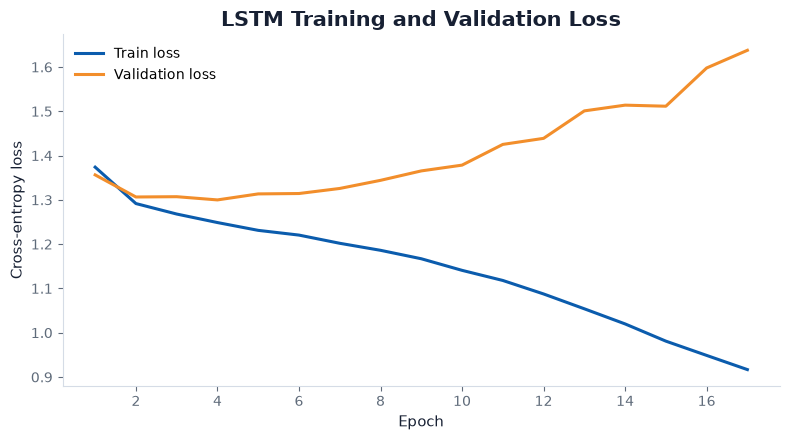

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hist.epoch, hist.train_loss, color=BLUE, linewidth=2.2, label='Train loss')
ax.plot(hist.epoch, hist.val_loss, color=ORANGE, linewidth=2.2, label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('LSTM Training and Validation Loss')
ax.legend()
despine(ax)
plt.tight_layout()
save_figure(fig, PROJECT_ROOT / 'reports' / 'figures' / 'model_training_loss.png')
fig

## 8. Test-Set Evaluation and Comparison

Macro-F1 is the headline metric because activation-style classes are imbalanced.


In [8]:
lstm_pred = predict_labels(lstm_model, x_test)
lstm_metrics = classification_metrics(y_test, lstm_pred)

results = pd.DataFrame([
    {'model': 'LSTM', 'accuracy': lstm_metrics['accuracy'], 'macro_f1': lstm_metrics['macro_f1']},
    *[{'model': k, **v} for k, v in baseline_results.items()],
]).sort_values('macro_f1', ascending=False).reset_index(drop=True)

display_labels = [clean_label(c) for c in CAMPAIGN_CLASSES]
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, lstm_pred, display_labels=display_labels, xticks_rotation=45, cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('LSTM Confusion Matrix (Test Set)')
plt.tight_layout()
save_figure(fig, PROJECT_ROOT / 'reports' / 'figures' / 'model_confusion_matrix.png')

fig2, ax2 = plt.subplots(figsize=(7, 4.5))
plot_df = results.set_index('model')[['accuracy', 'macro_f1']]
plot_df.plot(kind='bar', ax=ax2, color=[BLUE, ORANGE], rot=0)
ax2.set_ylim(0, 1)
ax2.set_ylabel('Score')
ax2.set_title('Model Comparison on Held-Out Test Set')
despine(ax2)
plt.tight_layout()
save_figure(fig2, PROJECT_ROOT / 'reports' / 'figures' / 'model_comparison.png')

print(classification_report(y_test, lstm_pred, target_names=CAMPAIGN_CLASSES, zero_division=0))
results

                         precision    recall  f1-score   support

new_customer_onboarding       1.00      0.98      0.99       329
      win_back_reminder       0.38      0.52      0.44      1035
       price_led_coupon       0.41      0.27      0.32      1660
      cross_sell_bundle       0.40      0.36      0.38      1565
         loyalty_reward       0.29      0.30      0.30       569
     seasonal_spotlight       0.43      0.73      0.54       512

               accuracy                           0.43      5670
              macro avg       0.49      0.53      0.50      5670
           weighted avg       0.43      0.43      0.42      5670



,model,accuracy,macro_f1
0,LSTM,0.425573,0.495353
1,random_forest,0.404586,0.436955
2,knn,0.367019,0.399616
3,stratified_random,0.225573,0.172976
4,majority_class,0.292769,0.075489


## 9. Save Artifacts for Notebook 04


In [9]:
save_model(lstm_model, str(ARTIFACT_DIR / 'journey_lstm.pt'))
joblib.dump(scaled.scaler, ARTIFACT_DIR / 'sequence_scaler.joblib')

np.save(ARTIFACT_DIR / 'train_idx.npy', split.train_idx)
np.save(ARTIFACT_DIR / 'val_idx.npy', split.val_idx)
np.save(ARTIFACT_DIR / 'test_idx.npy', split.test_idx)
np.save(ARTIFACT_DIR / 'y_test.npy', y_test)
np.save(ARTIFACT_DIR / 'lstm_test_pred.npy', lstm_pred)

metrics_payload = {
    'lstm': {'accuracy': lstm_metrics['accuracy'], 'macro_f1': lstm_metrics['macro_f1']},
    'baselines': baseline_results,
    'n_train': int(len(split.train_idx)),
    'n_val': int(len(split.val_idx)),
    'n_test': int(len(split.test_idx)),
    'hidden_size': 48,
    'learning_rate': 1e-3,
}
(ARTIFACT_DIR / 'nb03_metrics.json').write_text(json.dumps(metrics_payload, indent=2))
results.to_csv(PROJECT_ROOT / 'reports' / 'tables' / 'model_comparison.csv', index=False)
print('Saved artifacts:', sorted(p.name for p in ARTIFACT_DIR.iterdir()))

Saved artifacts: ['best_hyperparameters.json', 'journey_lstm.pt', 'lstm_test_pred.npy', 'nb03_metrics.json', 'nb04_metrics.json', 'sequence_scaler.joblib', 'test_idx.npy', 'train_idx.npy', 'val_idx.npy', 'y_test.npy']


## 10. Summary

This notebook trains leakage-safe baselines and an LSTM on future-window labeled journey sequences. Household-grouped splits and train-only scaling prevent optimistic leakage from repeated windows and preprocessing. Macro-F1, not accuracy alone, is used for comparison because class frequencies differ. The saved model and split indices feed hyperparameter search in notebook 04.

## References

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780.

Paszke, A., et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems, 32*.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
